# `earthlib` API Walkthrough

This notebook showcases the fundamental API design patterns and basic use patterns of the `earthlib` package.

## Background: all pixels are mixed

`earthlib` provides a curated spectral library for global land cover mapping. It features a collection of high quality spectral observations collected from open data portals and a series of modeled vegetation spectra that capture the optical dynamics of canopy vegetation.

Modeled vegetation spectra are included because most earth observing sensors — spaceborne or airborne sensors — measure at spatial resolutions much coarser than the scale of individual leaves. Satellite observations measure larger areas that include multiple organisms within a pixel — be they multiple trees, shrubs, or grasses — and canopy reflectance is optically distinct from leaf-level reflectance, driven by the scattering of photons among leaves in a canopy.

Quantifying these mixture dynamics — the inclusion of not only multiple organisms within a pixel but also multiple land cover types — is the purpose of spectral mixture analysis. The fundamental premise is that all pixels are mixed. Linear spectral unmixing provides an analytical framework for estimating the underlying fractions of land cover types within a pixel, given a representative reference of land cover observations.

## Reference spectra: an atomic representation of land surface components

- many land cover representations
- from multiple data providers
- capturing as much global variance in components
- optimized for maximum entropy
- narrowing in on the fundamental expressions land cover types

## Multi-sensor support: a new approach to analysis-ready data

- multiple earth observing sensors measure optical data at different wavelengths
- land cover data, sampled at fine native resolution, can be resampled to any of these sensors
- by using the same reference endmembers, you could run unmixing on multi sensor data, then fuse the results
- this provides a practical approach to sensor fusion that does not rely on sensor-level harmonization, but on data-driven harmonization

These points are all to be made in the paper and probably not here. But I'm saving it here for now!

In [1]:
%load_ext autoreload
%autoreload 2
    
# packages
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

import earthlib
from earthlib import library

# plotting defaults
mpl.style.use('ggplot')

# Spectral library

The `earthlib` reference spectral library are exposed via the `earthlib.library` instance.

This is an instance of athe `earthlib.endmembers.Spectra` class, which provides abstractions for working with spectral library data.

The three core components of the spectral library are:

- The reflectance data (the `.data` attribute), which represent the raw spectral estimates
- The library metadata (the `.metadata` attribute), which describe the attributes of each spectra
- The sensor specification (the `.sensor` attribute), which describes the band centers and other observation parameters

The `.data` attribute is simply a numpy ndarray

In [2]:
print(f"Number of reference spectra: {len(library)}")
print(f"Array shape: {library.data.shape}")
print(f"Data type: {library.data.dtype}")

Number of reference spectra: 317
Array shape: (317, 180)
Data type: float32


The `.metatdata` attribute is a pandas DataFrame

In [3]:
library.metadata.head(3)

,NAME,SOURCE,LEVEL_1,LEVEL_2,LEVEL_3,LEVEL_4,LAT,LON,NOTES
0,FS15R_FS4281,icraf-isric-soil-database,pervious,bare,soil,measured,-32.850000,137.533333,none
1,FS15R_FS4297,icraf-isric-soil-database,pervious,bare,soil,measured,-35.350000,144.850000,none
2,FS15R_FS4308,icraf-isric-soil-database,pervious,bare,soil,measured,-29.016667,152.033333,none


Metadata are hierarchically organized by "level"

In [4]:
# level 1: is water absorbed by this land cover type?
print("Level 1 classes:", library.metadata['LEVEL_1'].unique())

# level 2: core land cover types
print("Level 2 classes:", library.metadata['LEVEL_2'].unique())

# level 3: specific observation types
print("Level 3 classes:", library.metadata['LEVEL_3'].unique())

# level 4: measurement type
print("Level 4 classes:", library.metadata['LEVEL_4'].unique())

Level 1 classes: ['pervious' 'impervious']
Level 2 classes: ['bare' 'burn' 'npv' 'urban' 'vegetation']
Level 3 classes: ['soil' 'gravel' 'char' 'npv' 'bark' 'wood' 'litter' 'asphalt'
 'comp_shingle' 'concrete_tile' 'driveway' 'glass' 'manhole' 'metal'
 'other' 'paint' 'road' 'sidewalk' 'tile' 'wood_shingle' 'canopy']
Level 4 classes: ['measured' 'simulated']


The library can be indexed using this metadata

In [5]:
npv = library.metadata['LEVEL_2'] == "npv"
npv_library = library[npv]

print(f"Array shape: {npv_library.data.shape}")
npv_library.metadata.head(3)

Array shape: (42, 180)


,NAME,SOURCE,LEVEL_1,LEVEL_2,LEVEL_3,LEVEL_4,LAT,LON,NOTES
0,MCON_Tower_CWD1_Canopy,specevo,pervious,npv,npv,measured,37.066990,-119.195500,hyspiri simulation spectra
1,MCON_Tower_CWD2_Canopy,specevo,pervious,npv,npv,measured,37.066950,-119.195540,hyspiri simulation spectra
2,SJER_Plot361_NPV_T015,asd,pervious,npv,npv,measured,37.084376,-119.733826,hyspiri simulation spectra


Spectra can be indexed with arrays

In [6]:
random_idxs = [100, 200, 300]
sub_library = library[random_idxs]

print(f"Array shape: {sub_library.data.shape}")
print(f"Data type: {sub_library.data.dtype}")
sub_library.metadata.head()

Array shape: (3, 180)
Data type: float32


,NAME,SOURCE,LEVEL_1,LEVEL_2,LEVEL_3,LEVEL_4,LAT,LON,NOTES
0,FS21_FS9989,icraf-isric-soil-database,pervious,bare,soil,measured,-15.229167,23.266667,none
1,mobrmg.005-,asd,impervious,urban,other,measured,34.435800,-119.880400,urban reflectance spectra from santa barbara
2,v-LAI-6.7-LMA-0.006-CHL-58.8-N-2.2,prosail,pervious,vegetation,canopy,simulated,NaN,NaN,modeled canopy reflectance


Spectra can be subsampled to a random selection of spectra

In [7]:
sampled = library.subsample(n=10)

print(f"Array shape: {sampled.data.shape}")
print(f"Data type: {sampled.data.dtype}")
sampled.metadata.head(3)

Array shape: (10, 180)
Data type: float32


,NAME,SOURCE,LEVEL_1,LEVEL_2,LEVEL_3,LEVEL_4,LAT,LON,NOTES
0,FS21_FS125,icraf-isric-soil-database,pervious,bare,soil,measured,-3.910833,-73.371944,none
1,FS15R_FS5730,icraf-isric-soil-database,pervious,bare,soil,measured,5.883333,-7.333333,none
2,v-LAI-1.4-LMA-0.007-CHL-25.5-N-1.9,prosail,pervious,vegetation,canopy,simulated,NaN,NaN,modeled canopy reflectance


Spectra can also be subsampled randomly by class. you can pass different land cover classes (L1-L4) to the `by_type` parameter

In [8]:
vegetation = library.subsample(n=3, by_type="vegetation")

print(f"Array shape: {vegetation.data.shape}")
vegetation.metadata.head()

Array shape: (3, 180)


,NAME,SOURCE,LEVEL_1,LEVEL_2,LEVEL_3,LEVEL_4,LAT,LON,NOTES
0,v-LAI-2.8-LMA-0.009-CHL-52.3-N-2.2,prosail,pervious,vegetation,canopy,simulated,NaN,NaN,modeled canopy reflectance
1,v-LAI-5.0-LMA-0.006-CHL-20.9-N-2.1,prosail,pervious,vegetation,canopy,simulated,NaN,NaN,modeled canopy reflectance
2,v-LAI-1.4-LMA-0.005-CHL-38.4-N-2.4,prosail,pervious,vegetation,canopy,simulated,NaN,NaN,modeled canopy reflectance


# Sensors

The `earthlib` spectral library provides standardized spectral responses, sourced from a series of open spectral libraries, provided at 10nm sampling intervals across the visible-to-shortwave-infrared range.

This sampling is finer than the spectral sampling — and covers the spectral ranges of — many public and commercial electro optical sensors. 

This means `earthlib` can be easily spectrally resampled to match the specifications of common EO instruments.

The `earthlib.sensors` module provides instrument definitions for a series of common sensors.

The `earthlib.sensors.Sensor` class can be used to define custom sensors.

This class holds key information on band_centers, band_widths (aka FWHM), band_names, wavelength_unit, and measurement_unit.

These are used to handle common operations like spectral resampling, an are useful for describing other instrument metadata.

In [9]:
# print an example Sensor instance for Landsat 8
earthlib.sensors.Landsat8

Sensor(name='Landsat8', band_centers=array([0.482, 0.561, 0.655, 0.865, 1.609, 2.201], dtype=float32), band_widths=array([0.06 , 0.057, 0.037, 0.028, 0.085, 0.187], dtype=float32), band_names=['SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7'], band_descriptions=['blue', 'green', 'red', 'near infrared', 'shortwave infrared 1', 'shortwave infrared 2'], scale=2.75e-05, offset=-0.2, collection='LANDSAT/LC08/C02/T1_L2', wavelength_unit='micrometers', measurement_unit='reflectance')

A number of common EO sensors are supported by default in `earthlib`.

In [10]:
# list the sensors currently supported by default in earthlib
print(earthlib.sensors.supported_sensors.keys())

dict_keys(['AVNIR2', 'ASD', 'ASTER', 'DoveR', 'Earthlib', 'Landsat4', 'Landsat5', 'Landsat7', 'Landsat8', 'Landsat9', 'MODIS', 'NEON', 'PlanetScope', 'Sentinel2', 'SkySat', 'SuperDove', 'VIIRS'])


The `Sensor` class is useful for plotting the spectral responses for each observation.

Each `Spectra` object includes a `.sensor` attribute that tracks the sensor specifications.

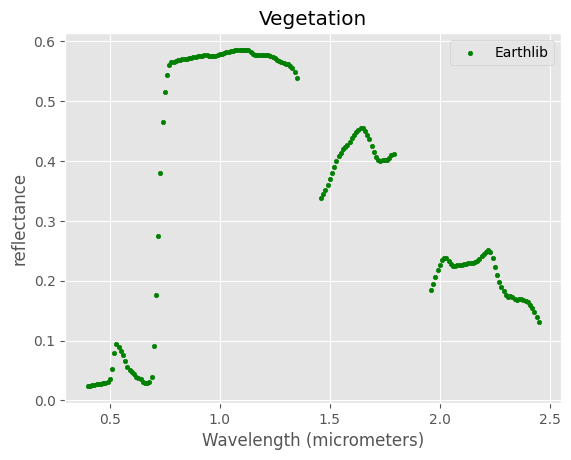

In [11]:
# let's plot a vegetation spectrum at the earthlib native spectral resolution
plt.scatter(
    vegetation.sensor.band_centers,
    vegetation.data[0],
    label=vegetation.sensor.name,
    color='green',
    s=10,
)

# labeling
plt.title("Vegetation")
plt.xlabel(f"Wavelength ({vegetation.sensor.wavelength_unit})")
plt.ylabel(vegetation.sensor.measurement_unit)
plt.legend()

The plot above plots the spectral response at each band center for a single vegetation spectrum.

But we can resample this spectral response to match the sensor characteristics of multiple EO sensors.

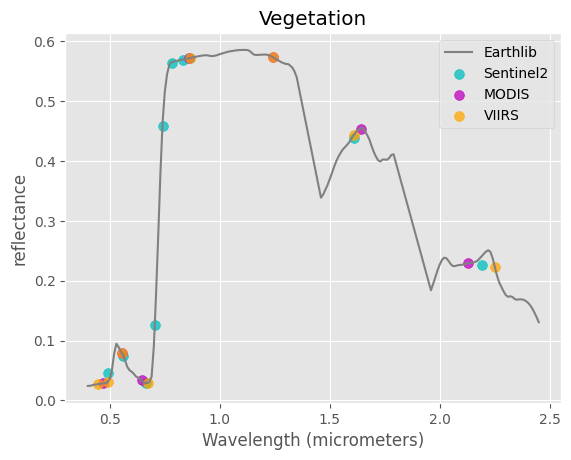

In [12]:
# we can resample the library to different sensor specifications
veg_s2 = vegetation.to_sensor(earthlib.sensors.Sentinel2)
veg_modis = vegetation.to_sensor(earthlib.sensors.MODIS)
veg_viirs = vegetation.to_sensor(earthlib.sensors.VIIRS)

# plot the sensor band centers
plt.plot(vegetation.sensor.band_centers, vegetation.data[0], label=vegetation.sensor.name, color='grey')
plt.scatter(veg_s2.sensor.band_centers, veg_s2.data[0], label=veg_s2.sensor.name, marker='o', color='c', alpha=0.75, s=50)
plt.scatter(veg_modis.sensor.band_centers, veg_modis.data[0], label=veg_modis.sensor.name, marker='o', color='m', alpha=0.75, s=50)
plt.scatter(veg_viirs.sensor.band_centers, veg_viirs.data[0], label=veg_viirs.sensor.name, marker='o', color='orange', alpha=0.75, s=50)

# labeling
plt.title('Vegetation')
plt.xlabel(f"Wavelength ({vegetation.sensor.wavelength_unit})")
plt.ylabel(vegetation.sensor.measurement_unit)
plt.legend()

The `Sensor` class can be used to define custom instrument specifications that may not be included in `earthlib` by default.

Let's use it to plot the band centers for CBERS (the China-Brazil Earth Resources Satellite [[EO Portal](https://www.eoportal.org/satellite-missions/cbers-1-2#hrcc-high-resolution-ccd-camera)]).

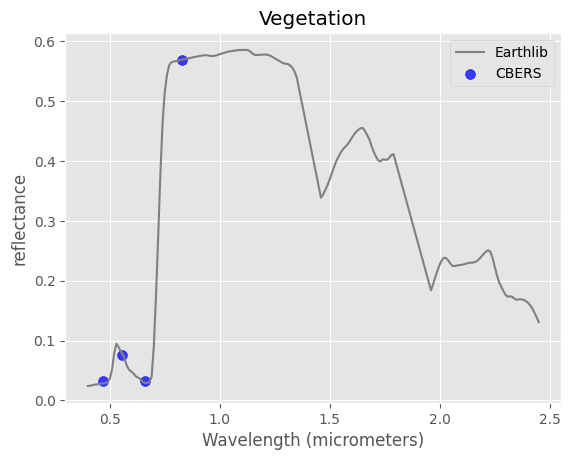

In [13]:
# define a custom sensor specification that's not included in earthlib
cbers = earthlib.sensors.Sensor(
    band_centers = [0.47, 0.555, 0.66, 0.83],
    band_widths = [0.1, 0.07, 0.06, 0.12],
    band_names = ["B1", "B2", "B3", "B4"],
    band_descriptions = ["blue", "green", "red", "near infrared"],
    name = "CBERS",
)

# resample to this sensor spec
veg_cbers = vegetation.to_sensor(cbers)

# plot the sensor band centers
plt.plot(vegetation.sensor.band_centers, vegetation.data[0], label=vegetation.sensor.name, color='grey')
plt.scatter(cbers.band_centers, veg_cbers.data[0], label=cbers.name, marker='o', color='blue', alpha=0.75, s=50)

# labeling
plt.title('Vegetation')
plt.xlabel(f"Wavelength ({vegetation.sensor.wavelength_unit})")
plt.ylabel(vegetation.sensor.measurement_unit)
plt.legend()

# Chaining commands together

`earthlib` was designed to make endmember subsampling and spectral resampling simple, particularly for use cases like spectral mixture analysis.

If you wanted to run a 3-class spectral mixture model using Sentinel-2 data, it is straightforward to get your reference endmembers.

In [14]:
# target sensor
s2 = earthlib.sensors.Sentinel2

# number of spectra to sample
n = 20

# sample the spectra at s2 wavelengths
veg_spectra = library.subsample(n=n, by_type='vegetation').to_sensor(s2)
npv_spectra = library.subsample(n=n, by_type='npv').to_sensor(s2)
bare_spectra = library.subsample(n=n, by_type='bare').to_sensor(s2)

If you want to store these sampled spectra as an ENVI spectral library on disk for later use, you can use the `.to_sli()` method.

In [15]:
# this writes the spectral library and the envi header file
veg_spectra.to_sli('veg.sli')

# which we can verify on disk
!cat veg.hdr

ENVI
samples = 10
lines = 20
bands = 1
header offset = 0
file type = ENVI Spectral Library
data type = 4
interleave = bsq
sensor type = Sentinel2
byte order = 0
spectra names = { v-LAI-3.7-LMA-0.005-CHL-43.1-N-1.7 , v-LAI-3.9-LMA-0.006-CHL-44.2-N-2.4 , v-LAI-2.1-LMA-0.006-CHL-25.5-N-2.0 , v-LAI-6.8-LMA-0.007-CHL-34.1-N-2.0 , v-LAI-4.9-LMA-0.008-CHL-17.6-N-2.1 , v-LAI-4.9-LMA-0.008-CHL-17.6-N-2.1 , v-LAI-3.9-LMA-0.006-CHL-44.2-N-2.4 , v-LAI-4.3-LMA-0.009-CHL-11.8-N-2.4 , v-LAI-1.8-LMA-0.016-CHL-30.2-N-2.4 , v-LAI-5.8-LMA-0.008-CHL-15.1-N-1.8 , v-LAI-5.8-LMA-0.007-CHL-55.2-N-2.3 , v-LAI-1.5-LMA-0.012-CHL-12.8-N-2.4 , v-LAI-1.5-LMA-0.012-CHL-12.8-N-2.4 , v-LAI-4.6-LMA-0.009-CHL-12.0-N-2.4 , v-LAI-4.1-LMA-0.017-CHL-10.2-N-1.9 , v-LAI-3.7-LMA-0.013-CHL-16.7-N-2.1 , v-LAI-7.5-LMA-0.006-CHL-37.8-N-2.0 , v-LAI-5.8-LMA-0.008-CHL-15.1-N-1.8 , v-LAI-6.4-LMA-0.013-CHL-11.9-N-2.0 , v-LAI-8.6-LMA-0.012-CHL-59.4-N-1.9 }
wavelength units = micrometers
wavelength = { 0.494 , 0.56 , 0.665 , 0.704 , 0.74

# Closing

`earthlib` is designed to provide a high quality, standardized spectral library that is optimized for land cover mapping, particularly with spectral mixture analysis.

It provides a simple API for common spectral operations like resampling and data i/o in python.

Working across EO sensors is straightforward, providing a set of reference spectra that can be used to retrieve normalized fractional cover estimates across instruments.

I hope you find it useful.